# YT-Diag — project walkthrough

Run this top to bottom to see the whole pipeline on real data, and to **check the
claims** in `02_Data/eda.md` and `CHANGELOG.md` yourself rather than taking them
on trust. Every section ends with something you can verify.

**Ground rules for this notebook** (worth keeping if you add cells):

- It is an *interface* to the pipeline, not a second copy of it. Cells import from
  `02_Data/` and `03_Models/` and call the real functions.
- Never paste label, split or cleaning logic into a cell. If you need it, import it.
- Restart-and-run-all must work. No hidden state, no cell that depends on you having
  run something out of order.
- Nothing here writes to the dataset. The one cell that could (`clean_retrospective`)
  is run in its read-only default mode.

**Any Python environment works.** The next cell bootstraps: it finds the repo, installs
whatever is missing into *this* kernel, and tells you precisely what to do if the dataset
itself is absent. It is idempotent, so re-running costs nothing.

In [1]:
# ---------------------------------------------------------------- BOOTSTRAP
# Runs anywhere: the project venv, a bare python3, Colab, a grader's laptop.
# Installs into THIS kernel (sys.executable), never a different interpreter.
import importlib.util, os, subprocess, sys

AUTO_INSTALL = True          # set False to only report what is missing

REQUIRED = {                 # import name -> pip requirement
    "numpy": "numpy>=1.26", "pandas": "pandas>=2.2", "matplotlib": "matplotlib>=3.8",
    "sklearn": "scikit-learn>=1.5", "PIL": "pillow>=10",
}
OPTIONAL = {                 # baselines fall back to sklearn's HistGradientBoosting
    "xgboost": "xgboost>=2.1",
}

def _missing(mapping):
    return {m: spec for m, spec in mapping.items() if importlib.util.find_spec(m) is None}

def _install(specs):
    print(f"installing into {sys.executable}:")
    for s in specs: print(f"   {s}")
    r = subprocess.run([sys.executable, "-m", "pip", "install", "-q", *specs],
                       capture_output=True, text=True)
    if r.returncode:
        print(r.stdout[-1500:]); print(r.stderr[-1500:])
        raise SystemExit("pip install failed -- install the packages above by hand")

need = _missing(REQUIRED)
if need and AUTO_INSTALL:
    _install(list(need.values()))
elif need:
    raise SystemExit("missing: " + ", ".join(need.values()) + "  (set AUTO_INSTALL=True)")

opt = _missing(OPTIONAL)
if opt and AUTO_INSTALL:
    try:
        _install(list(opt.values()))
    except SystemExit:
        # xgboost needs libomp on macOS; not fatal, the baselines degrade cleanly
        print("xgboost unavailable -- baselines will use HistGradientBoosting instead")

# ------------------------------------------------------------- LOCATE REPO
# Walk up from the working directory rather than assuming notebooks/ or root,
# so this survives being opened from anywhere.
def _find_root(start):
    d = os.path.abspath(start)
    for _ in range(6):
        if all(os.path.isdir(os.path.join(d, x)) for x in ("02_Data", "03_Models")):
            return d
        parent = os.path.dirname(d)
        if parent == d:
            break
        d = parent
    return None

ROOT = _find_root(os.getcwd())
if ROOT is None:
    print("Could not find the repo (looked for 02_Data/ and 03_Models/ above")
    print(f"  {os.getcwd()}).")
    print("Open this notebook from inside the clone, or in Colab run:")
    print("    !git clone <repo-url> && %cd yt-diag")
    raise SystemExit("repo not found")

for sub in ("02_Data", "03_Models"):
    path = os.path.join(ROOT, sub)
    if path not in sys.path:
        sys.path.insert(0, path)
DATA = os.path.join(ROOT, "02_Data", "processed")

import json, warnings
warnings.filterwarnings("ignore", category=UserWarning)
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

SEED = 0                      # every random choice below uses this
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)

# --------------------------------------------------------------- CHECK DATA
# Packages are not enough: the images live in Git LFS, and an un-pulled clone
# has text pointer files where JPEGs should be. Say so plainly rather than
# failing later inside PIL.
print(f"root   : {ROOT}")
print(f"python : {sys.version.split()[0]}  ({sys.executable})")

if not os.path.isdir(DATA):
    print()
    print("DATASET MISSING: 02_Data/processed/ not found.")
    print("  The notebook's later sections need it. Fetch it, or ask a teammate.")
else:
    n_done = sum(1 for c in os.listdir(DATA)
                 if os.path.isdir(os.path.join(DATA, c))
                 for v in os.listdir(os.path.join(DATA, c))
                 if os.path.exists(os.path.join(DATA, c, v, ".done")))
    print(f"videos : {n_done} completed")
    stub = None
    for c in sorted(os.listdir(DATA)):
        cd = os.path.join(DATA, c)
        if not os.path.isdir(cd): continue
        for v in sorted(os.listdir(cd))[:1]:
            for name in ("thumbnail.webp", "thumbnail.jpg"):
                fp = os.path.join(cd, v, name)
                if os.path.exists(fp):
                    with open(fp, "rb") as f:
                        stub = f.read(40).startswith(b"version https://git-lfs")
                    break
        if stub is not None: break
    if stub:
        print()
        print("IMAGES ARE GIT-LFS POINTERS, not real files. Run:")
        print("    git lfs install && git lfs pull")
        print("  (~2.8 GB. Sections 3 and 4 need it; the rest works without.)")
    elif stub is False:
        print("images : real files (Git LFS pulled)")

root   : /Users/emmanuelgyabaah/GitHub/yt-diag
python : 3.11.15  (/Users/emmanuelgyabaah/GitHub/yt-diag/.venv/bin/python3.11)
videos : 1860 completed
images : real files (Git LFS pulled)


## 1. What one video actually is

Nothing in this project is a database — every video is a folder on disk. That is what
makes the pipeline resumable: a crash just means re-running the same command.

In [2]:
from clean_retrospective import done_videos

videos = list(done_videos(DATA))   # generator -> list, we iterate it repeatedly
print(f"{len(videos)} completed videos")

# a video with the full set of artefacts, chosen deterministically
category, vid, vdir = next(v for v in videos if os.path.exists(os.path.join(v[2], "audio_features.json")))
print(f"\nexample: {category}/{vid}\n")
for f in sorted(os.listdir(vdir)):
    p = os.path.join(vdir, f)
    size = sum(os.path.getsize(os.path.join(p, x)) for x in os.listdir(p)) if os.path.isdir(p) else os.path.getsize(p)
    print(f"  {f:26s} {size/1024:8.1f} KB")

1860 completed videos

example: comedy/-ERhH_wltqU

  .done                           0.0 KB
  audio_features.json             5.0 KB
  captions.en.srt               101.3 KB
  frames                       1787.9 KB
  label.json                      0.3 KB
  metadata.json                   2.4 KB
  metadata_extra.json             0.4 KB
  thumbnail.webp                 81.2 KB
  transcript.txt                 47.6 KB
  transcript_clean.txt           17.5 KB
  transcript_info.json            0.1 KB
  visual_features.json            0.8 KB


In [3]:
meta = json.load(open(os.path.join(vdir, "metadata.json")))
extra = json.load(open(os.path.join(vdir, "metadata_extra.json")))
print("title      :", meta["title"][:70])
print("channel    :", meta.get("channel"), f"({meta.get('channel_follower_count'):,} subs)")
print("duration   :", meta["duration"], "s")
print("views      :", f"{meta['view_count']:,}")
print("published  :", extra.get("published_at_utc"), "| language:", extra.get("default_audio_language") or extra.get("default_language"))
print("is_short   :", extra.get("is_short"))

title      : Kanchana 3 - Back to Back Comedy Scenes 😂 | Raghava Lawrence | Kovai S
channel    : None (2,090,000 subs)
duration   : 2091 s
views      : 5,876,497
published  : 2026-06-04T13:00:09Z | language: ta
is_short   : false


## 2. The transcript repair — check it yourself

**Claim to verify:** YouTube auto-captions repeat every phrase about three times, because
captions scroll in overlapping windows. If true, word counts were inflated ~3× and every
text statistic was really measuring repetition.

`dup8_ratio` is the fraction of 8-word sequences that are repeats of an earlier one.

In [4]:
from clean_retrospective import dup8_ratio, parse_srt_text_lines, dedup_rolling_lines

# pick a video whose transcript came from auto-captions and was rebuilt
sample = None
for c, v, d in videos:
    info = os.path.join(d, "transcript_info.json")
    if (os.path.exists(os.path.join(d, "transcript_clean.txt"))
            and os.path.exists(os.path.join(d, "transcript.txt"))
            and json.load(open(info)).get("source") == "auto_captions"):
        raw = open(os.path.join(d, "transcript.txt"), encoding="utf-8", errors="replace").read()
        if len(raw.split()) > 400:
            sample = (c, v, d); break

c, v, d = sample
raw = open(os.path.join(d, "transcript.txt"), encoding="utf-8", errors="replace").read()
clean = open(os.path.join(d, "transcript_clean.txt"), encoding="utf-8", errors="replace").read()
print(f"{c}/{v}\n")
print("RAW (first 300 chars) — look for the repetition:")
print(" ", repr(raw[:300]), "\n")
print("CLEANED:")
print(" ", repr(clean[:300]), "\n")
print(f"words   raw {len(raw.split()):5d}  ->  clean {len(clean.split()):5d}   (ratio {len(clean.split())/len(raw.split()):.2f})")
print(f"dup8    raw {dup8_ratio(raw.split()):.3f}  ->  clean {dup8_ratio(clean.split()):.3f}")

comedy/-ERhH_wltqU

RAW (first 300 chars) — look for the repetition:
  'Oh my god, the big guy has arrived. The pilgrim has arrived. The pilgrim has arrived. The pilgrim has arrived. Hi Put it like that, Put it like that, Put it like that, my my my dance is great, dance is great, dance is great, we are sharing love here we are sharing love here we are sharing love here ' 

CLEANED:
  "Oh my god, the big guy has arrived.\nThe pilgrim has arrived.\nHi\nPut it like that,\nmy\ndance is great,\nwe are sharing love here\n.\nI'm also sharing.\nWhat a blessing. [Screaming]\nHow was the Super America trip\n? I haven't\nseen you for six months. I was so happy. I'm like this.\nWhat is my daughter doing?" 

words   raw  9445  ->  clean  3478   (ratio 0.37)
dup8    raw 0.302  ->  clean 0.003


In [5]:
# Does it hold across the dataset? Sample 120 rebuilt auto-caption transcripts.
import random
rng = random.Random(SEED)
cands = [(c, v, d) for c, v, d in videos
         if os.path.exists(os.path.join(d, "transcript_clean.txt"))
         and os.path.exists(os.path.join(d, "transcript.txt"))]
rows = []
for c, v, d in rng.sample(cands, 120):
    rw = open(os.path.join(d, "transcript.txt"), encoding="utf-8", errors="replace").read().split()
    cw = open(os.path.join(d, "transcript_clean.txt"), encoding="utf-8", errors="replace").read().split()
    if len(rw) < 20: continue
    rows.append({"raw_dup8": dup8_ratio(rw), "clean_dup8": dup8_ratio(cw), "word_ratio": len(cw)/len(rw)})
rep = pd.DataFrame(rows)
print(rep.describe().loc[["count", "mean", "50%", "max"]].round(3))
print("\n-> raw dup8 clusters near 0.35 (each phrase ~3x); cleaned near 0.")

       raw_dup8  clean_dup8  word_ratio
count   113.000     113.000     113.000
mean      0.343       0.012       0.352
50%       0.347       0.000       0.343
max       0.827       0.866       0.792

-> raw dup8 clusters near 0.35 (each phrase ~3x); cleaned near 0.


## 3. The 20 frames, and why they are not evenly spaced

Twelve of the twenty land in the **first 60 seconds**; the remaining eight cover
everything after. Viewers decide whether to keep watching in the opening seconds, so
that is where the retention signal is. Even spacing would spend most frames on the part
of the video most viewers never reach.

duration 2091s -> frame timestamps (s):
  [2.5, 7.5, 12.5, 17.5, 22.5, 27.5, 32.5, 37.5, 42.5, 47.5, 52.5, 57.5, 186.9, 440.8, 694.7, 948.6, 1202.4, 1456.3, 1710.2, 1964.1]

12 of 20 frames are inside the first 60 seconds


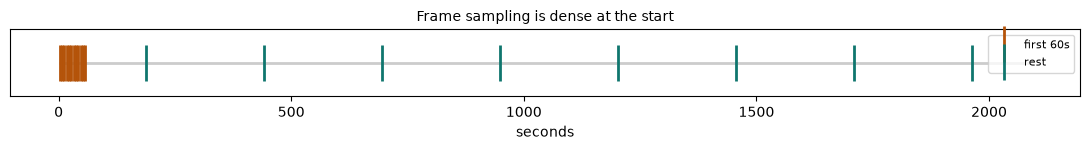

In [6]:
from collect_and_extract import compute_frame_timestamps

dur = meta["duration"]
ts = compute_frame_timestamps(dur, 20)
print(f"duration {dur}s -> frame timestamps (s):")
print(" ", [round(t, 1) for t in ts])
print(f"\n{sum(1 for t in ts if t <= 60)} of 20 frames are inside the first 60 seconds")

fig, ax = plt.subplots(figsize=(11, 1.6))
ax.hlines(0, 0, dur, color="0.8", lw=2)
ax.plot([t for t in ts if t <= 60], [0]*sum(1 for t in ts if t <= 60), "|", ms=26, mew=2, color="#b45309", label="first 60s")
ax.plot([t for t in ts if t > 60], [0]*sum(1 for t in ts if t > 60), "|", ms=26, mew=2, color="#0f766e", label="rest")
ax.set_yticks([]); ax.set_xlabel("seconds"); ax.legend(loc="upper right", fontsize=8)
ax.set_title("Frame sampling is dense at the start", fontsize=10); plt.tight_layout(); plt.show()

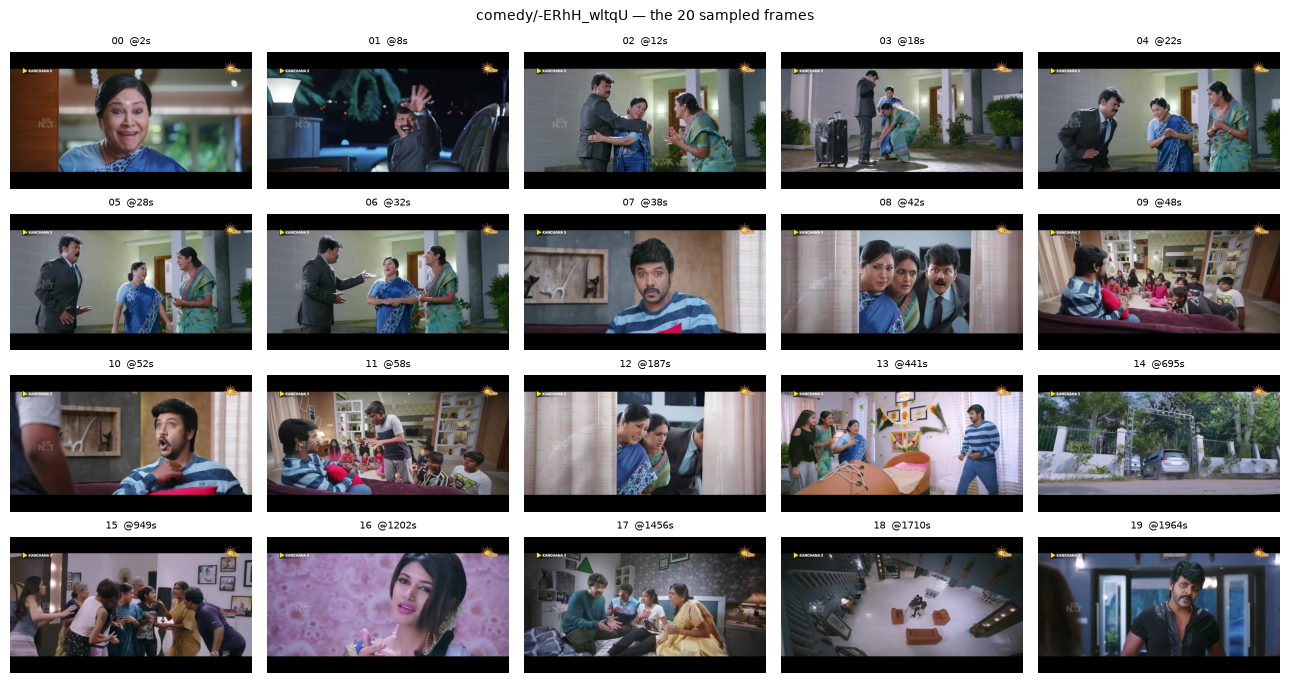

In [7]:
# The frames themselves
from PIL import Image
frames = sorted(os.listdir(os.path.join(vdir, "frames")))
fig, axes = plt.subplots(4, 5, figsize=(13, 7))
for ax, fn, t in zip(axes.ravel(), frames, ts):
    ax.imshow(Image.open(os.path.join(vdir, "frames", fn)))
    ax.set_title(f"{fn.replace('frame_','').replace('.jpg','')}  @{t:.0f}s", fontsize=7)
    ax.axis("off")
plt.suptitle(f"{category}/{vid} — the 20 sampled frames", fontsize=10)
plt.tight_layout(); plt.show()

## 4. The engineered features, including the colour-temperature fix

`visual_features.json` is 15 hand-designed numbers; `audio_features.json` is 92
(88 standard eGeMAPS values plus 4 pause measurements). Hand-designed features are
*interpretable*: the explanation layer can say "dark, no face" rather than "neuron 291
was low".

**Claim to verify:** the old colour-temperature values were physically impossible, and
the corrected ones are plausible.

In [8]:
vis = json.load(open(os.path.join(vdir, "visual_features.json")))
aud = json.load(open(os.path.join(vdir, "audio_features.json")))
print("visual_features.json — thumbnail block:")
for k, val in vis["thumbnail"].items():
    print(f"   {k:24s} {val}")
print("\nvisual_features.json — frame aggregates + CCT provenance:")
for k, val in vis.items():
    if k != "thumbnail":
        print(f"   {k:24s} {val}")
print("\naudio_features.json — pauses:", aud["pauses"])
print(f"audio_features.json — {len(aud['egemaps'])} eGeMAPS values, e.g.")
for k in list(aud["egemaps"])[:4]:
    print(f"   {k:48s} {aud['egemaps'][k]:.3f}")

visual_features.json — thumbnail block:
   cct                      5011.749364249898
   brightness               118.68961588541667
   saturation               84.65308159722223
   contrast                 77.71253570674585
   has_face                 True
   face_count               2
   max_face_area_ratio      0.08567816840277778
   face_centrality          0.27871227155010697

visual_features.json — frame aggregates + CCT provenance:
   frames_mean_cct          6941.341536326816
   frames_std_cct           1235.4484439526798
   frames_mean_brightness   88.0454475368924
   frames_mean_saturation   53.493463704427086
   frames_mean_contrast     67.77539898986507
   frames_has_face_ratio    0.9
   frames_mean_max_face_area_ratio 0.03369661458333333
   cct_thumbnail_valid      True
   cct_frames_valid         20
   cct_frames_total         20
   cct_version              3
   cct_recomputed_at_utc    2026-09-01T16:42:50Z
   cct_method               nearest_planckian_locus_cie1960uv_1pc

D65 white (equal linear RGB) -> 6500.6 K   [textbook: 6504]
warm  (1.0, 0.6, 0.3)        -> 3675.6 K
cool  (0.6, 0.75, 1.0)       -> 9611.6 K
pure green                   -> None  (far from the Planckian locus, so undefined)

The OLD implementation returned 5520 K for white and up to 5.0e9 K for some frames.

frames_mean_cct over 1857 videos: min 2553  median 5666  max 15679 K


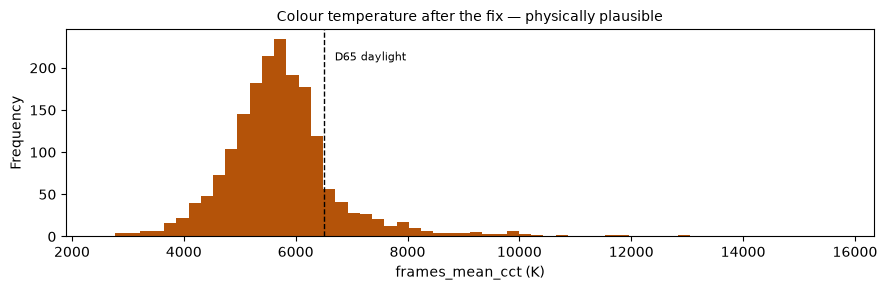

In [9]:
# The correctness test: a known colour must give a known temperature.
from collect_and_extract import correlated_color_temp, srgb_to_linear, MAX_DUV
print("D65 white (equal linear RGB) ->", round(correlated_color_temp((1,1,1)), 1), "K   [textbook: 6504]")
print("warm  (1.0, 0.6, 0.3)        ->", round(correlated_color_temp((1,.6,.3)), 1), "K")
print("cool  (0.6, 0.75, 1.0)       ->", round(correlated_color_temp((.6,.75,1)), 1), "K")
print("pure green                   ->", correlated_color_temp((0,1,0)), " (far from the Planckian locus, so undefined)")
print("\nThe OLD implementation returned 5520 K for white and up to 5.0e9 K for some frames.")

# distribution across the dataset, after the fix
ccts = []
for c, v, d in videos:
    p = os.path.join(d, "visual_features.json")
    if os.path.exists(p):
        m = json.load(open(p)).get("frames_mean_cct")
        if m: ccts.append(m)
s = pd.Series(ccts)
print(f"\nframes_mean_cct over {len(s)} videos: min {s.min():.0f}  median {s.median():.0f}  max {s.max():.0f} K")
s.plot.hist(bins=60, figsize=(9,3), color="#b45309")
plt.axvline(6504, color="k", ls="--", lw=1); plt.text(6700, plt.ylim()[1]*.85, "D65 daylight", fontsize=8)
plt.xlabel("frames_mean_cct (K)"); plt.title("Colour temperature after the fix — physically plausible", fontsize=10)
plt.tight_layout(); plt.show()

## 5. Label-blind descriptive EDA

The feature EDA first describes what the modalities contain **before** asking whether they
predict the target. Its core loader drops the label before any join or summary, and every
table separates regular videos from Shorts. Outcome-aware dashboard panels are confined to
the pre-specified seed-0 channel-grouped training partition and are descriptive only. This
prevents two common mistakes:

1. selecting features after looking at outcomes across the full dataset; and
2. reporting a pooled average that is actually just a Shorts-versus-regular difference.

The cells below call the functions in `02_Data/eda_features.py`; they do not copy the
grouping or summary logic into the notebook. Values are medians unless stated otherwise.

In [10]:
from eda_features import (load as load_feature_eda, dataset_table,
                          visual_table, audio_speech_table,
                          category_format_pivot, modality_coverage_table,
                          training_partition, correlation_tables,
                          audio_correlation_table, outcome_association_table)

feature_eda = load_feature_eda(DATA)
assert "label" not in feature_eda.columns
dataset_eda = dataset_table(feature_eda)
visual_eda = visual_table(feature_eda)
audio_eda = audio_speech_table(feature_eda)
pivot_eda = category_format_pivot(feature_eda)
coverage_eda = modality_coverage_table(feature_eda)

print(f"label-blind EDA rows: {len(feature_eda)}; label present: {'label' in feature_eda.columns}")
print("\noverall dataset profile by format:")
overall = dataset_eda[dataset_eda.category == "all"]
print(overall[["format", "n", "duration_sec_median", "age_days_median",
               "transcript_usable_pct", "audio_present_pct"]]
      .round(1).to_string(index=False))

label-blind EDA rows: 1860; label present: False

overall dataset profile by format:
 format   n  duration_sec_median  age_days_median  transcript_usable_pct  audio_present_pct
regular 880                843.0            190.0                   92.4               96.8
 Shorts 975                 37.0             13.0                   60.2               99.3


In [11]:
print("compact category × format pivot table:")
key_columns = [
    "category", "n__regular", "n__shorts",
    "views_median__regular", "views_median__shorts",
    "duration_sec_median__regular", "duration_sec_median__shorts",
    "usable_transcript_pct__regular", "usable_transcript_pct__shorts",
    "thumb_brightness_median__regular", "thumb_brightness_median__shorts",
    "thumb_cct_k_median__regular", "thumb_cct_k_median__shorts",
]
display(pivot_eda[key_columns].round(1))
print("The complete CSV also includes subscribers, faces, pauses, speech density and modality coverage.")

compact category × format pivot table:


,category,n__regular,n__shorts,views_median__regular,views_median__shorts,duration_sec_median__regular,duration_sec_median__shorts,usable_transcript_pct__regular,usable_transcript_pct__shorts,thumb_brightness_median__regular,thumb_brightness_median__shorts,thumb_cct_k_median__regular,thumb_cct_k_median__shorts
0,comedy,198,265,807284.0,1730567.0,1288.0,33.0,87.9,57.0,130.3,156.3,5068.0,5561.5
1,howto,144,229,1387603.5,541613.0,685.5,25.0,97.2,45.4,172.7,158.3,5703.6,5628.5
2,product_reviews,304,177,6708.5,28771.0,475.5,39.0,95.1,65.0,141.3,148.4,5559.6,5327.4
3,vlogs,234,304,253435.5,336781.5,1235.0,52.0,89.7,71.4,147.2,148.2,5188.6,5392.8


The complete CSV also includes subscribers, faces, pauses, speech density and modality coverage.


In [12]:
# Outcome-aware EDA is confined to one pre-specified channel-grouped training
# partition. It is descriptive only and is never used to choose model inputs.
eda_train = training_partition(feature_eda, DATA, seed=0)
correlation_eda, correlation_n = correlation_tables(eda_train)
audio_correlation_eda = audio_correlation_table(feature_eda)
outcome_eda = outcome_association_table(eda_train)

print(f"correlation rows: {len(eda_train)} videos from {eda_train.channel_id.nunique()} channels")
print("\nstrongest pooled rank associations with log1p views:")
display(outcome_eda[["feature", "rho_overall", "rho_regular", "rho_shorts",
                     "format_sign_reversal", "pooled_vs_format_reversal"]]
        .head(10).round(3))
upper = np.triu_indices_from(audio_correlation_eda, k=1)
print(f"\neGeMAPS pairs with |Spearman rho| > 0.95: "
      f"{int((audio_correlation_eda.abs().to_numpy()[upper] > 0.95).sum())}")

correlation rows: 1113 videos from 798 channels

strongest pooled rank associations with log1p views:


,feature,rho_overall,rho_regular,rho_shorts,format_sign_reversal,pooled_vs_format_reversal
0,log1p subscribers,0.705,0.750,0.676,False,False
7,frame brightness,0.195,0.186,0.150,False,False
15,sound level (dBp),0.176,0.168,0.097,False,False
6,thumbnail brightness (crop),0.170,0.205,0.121,False,False
3,Shorts indicator,0.155,NaN,NaN,False,False
13,pause ratio,-0.151,-0.214,0.025,True,True
10,thumbnail face present,0.145,0.169,0.143,False,False
14,pauses/min,-0.141,-0.188,0.024,True,True
1,log1p age (days),0.132,-0.015,0.380,True,True
9,thumbnail contrast,-0.093,-0.164,0.087,True,True



eGeMAPS pairs with |Spearman rho| > 0.95: 23


In [13]:
print("visual profile by format:")
overall_vis = visual_eda[visual_eda.category == "all"]
print(overall_vis[["format", "thumb_cct_k_median", "frames_cct_k_median",
                   "thumb_brightness_raw_median", "thumb_brightness_crop_median",
                   "frames_brightness_median", "thumb_face_present_pct",
                   "cct_feature_valid_pct", "cct_frames_complete_pct"]]
      .round(1).to_string(index=False))

from sklearn.metrics import roc_auc_score
known = feature_eda.dropna(subset=["meta__is_short"])
def direction_free_auc(column):
    x = known[[column, "meta__is_short"]].dropna()
    score = roc_auc_score(x["meta__is_short"], x[column])
    return max(score, 1 - score)

print(f"\nformat AUC from raw thumbnail brightness : {direction_free_auc('vis__thumb_brightness'):.3f}")
print(f"format AUC after heuristic content crop   : {direction_free_auc('thumb_crop_brightness'):.3f}")
print("The crop is a diagnostic heuristic, not a verified pillarbox detector.")

visual profile by format:
 format  thumb_cct_k_median  frames_cct_k_median  thumb_brightness_raw_median  thumb_brightness_crop_median  frames_brightness_median  thumb_face_present_pct  cct_feature_valid_pct  cct_frames_complete_pct
regular              5312.4               5762.1                        144.3                         145.1                     136.4                    73.6                   99.3                     85.2
 Shorts              5453.2               5603.0                         80.3                         151.8                     148.4                    69.1                   99.8                     96.0

format AUC from raw thumbnail brightness : 0.925
format AUC after heuristic content crop   : 0.559
The crop is a diagnostic heuristic, not a verified pillarbox detector.


In [14]:
print("audio and edited-speech profile by format:")
overall_aud = audio_eda[audio_eda.category == "all"]
print(overall_aud[["format", "pause_ratio_median", "pauses_per_min_median",
                   "zero_pause_pct", "sound_level_dbp_median",
                   "loudness_variability_median",
                   "edited_speech_density_wpm_median",
                   "speech_density_coverage_pct"]]
      .round(2).to_string(index=False))
print("\nCaution: VAD silence is not ground-truth human pausing; music may be classified as voice.")
print("Edited speech density is words retained per video minute, not physical articulation rate.")
print("Equivalent level describes the whole mixed track; it is not an audio-quality grade.")

audio and edited-speech profile by format:
 format  pause_ratio_median  pauses_per_min_median  zero_pause_pct  sound_level_dbp_median  loudness_variability_median  edited_speech_density_wpm_median  speech_density_coverage_pct
regular                0.04                   3.69            3.05                  -20.71                         0.67                            151.07                        92.39
 Shorts                0.00                   0.00           65.08                  -16.04                         0.55                            189.68                        60.21

Caution: VAD silence is not ground-truth human pausing; music may be classified as voice.
Edited speech density is words retained per video minute, not physical articulation rate.
Equivalent level describes the whole mixed track; it is not an audio-quality grade.


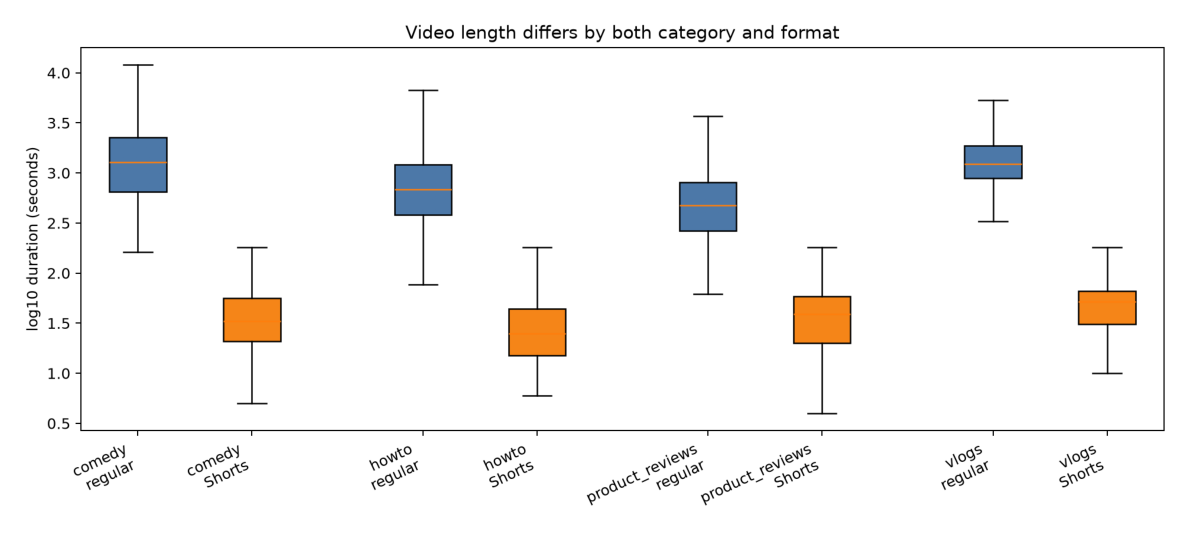

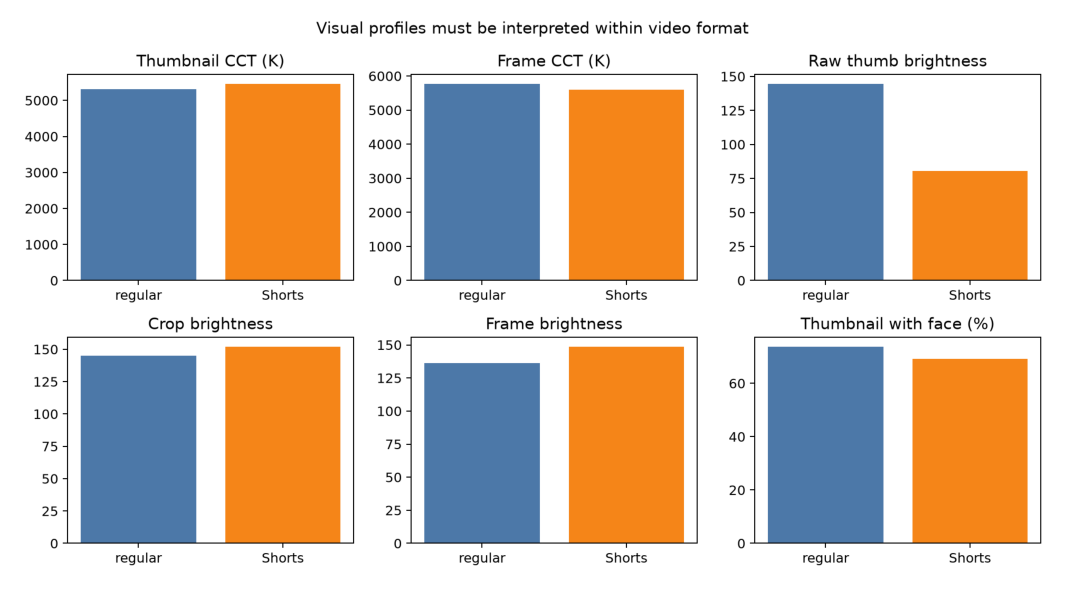

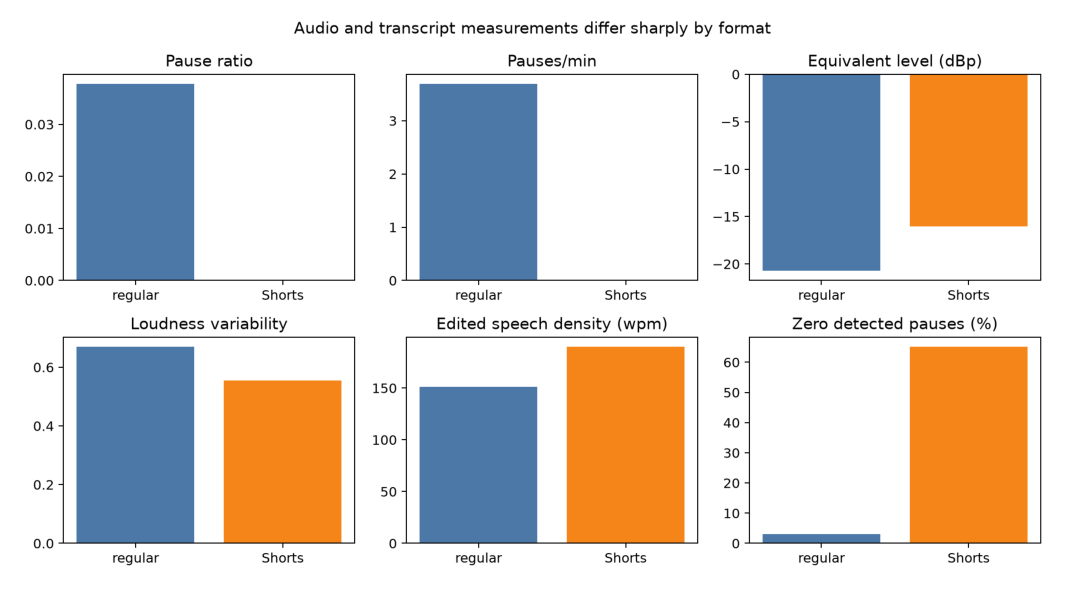

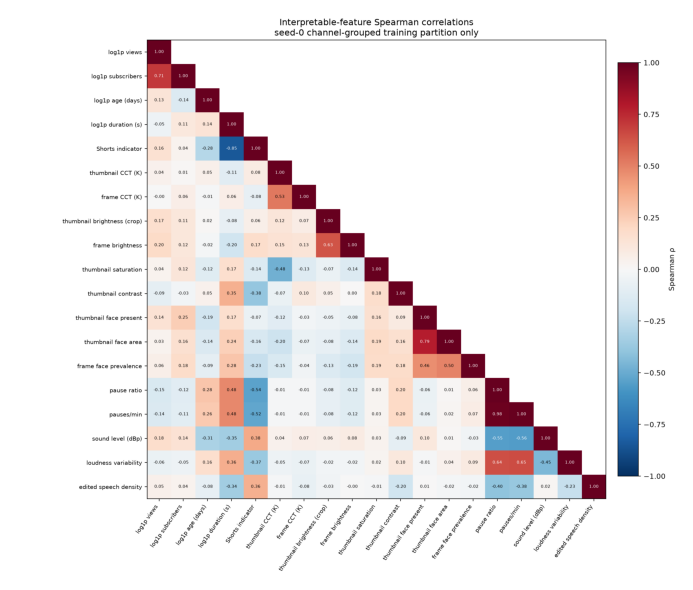

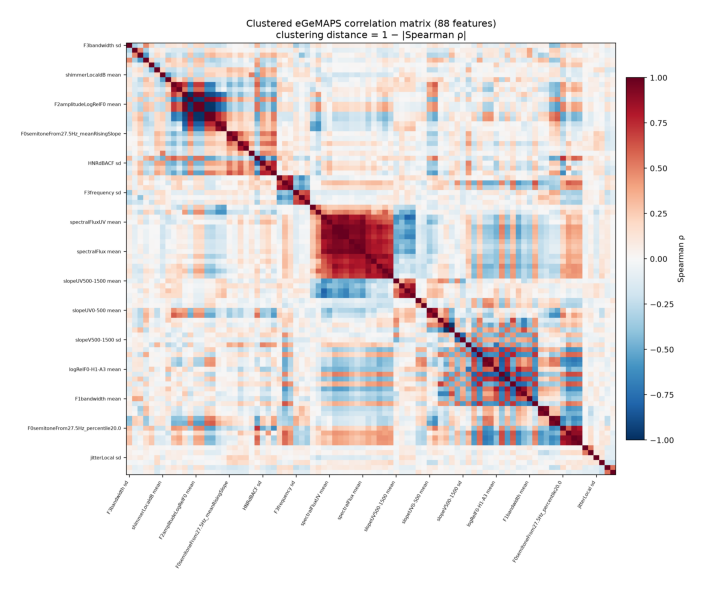

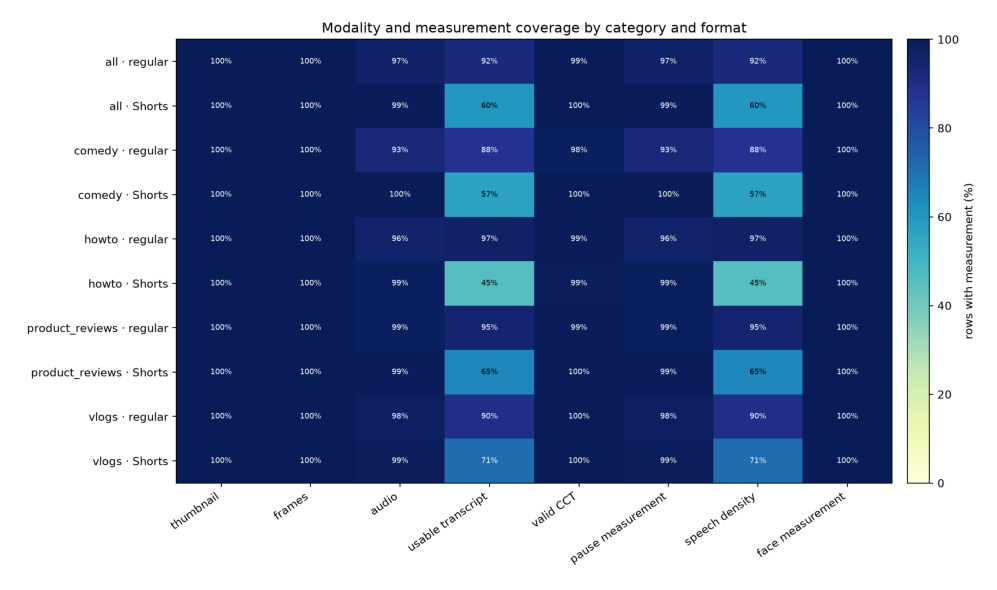

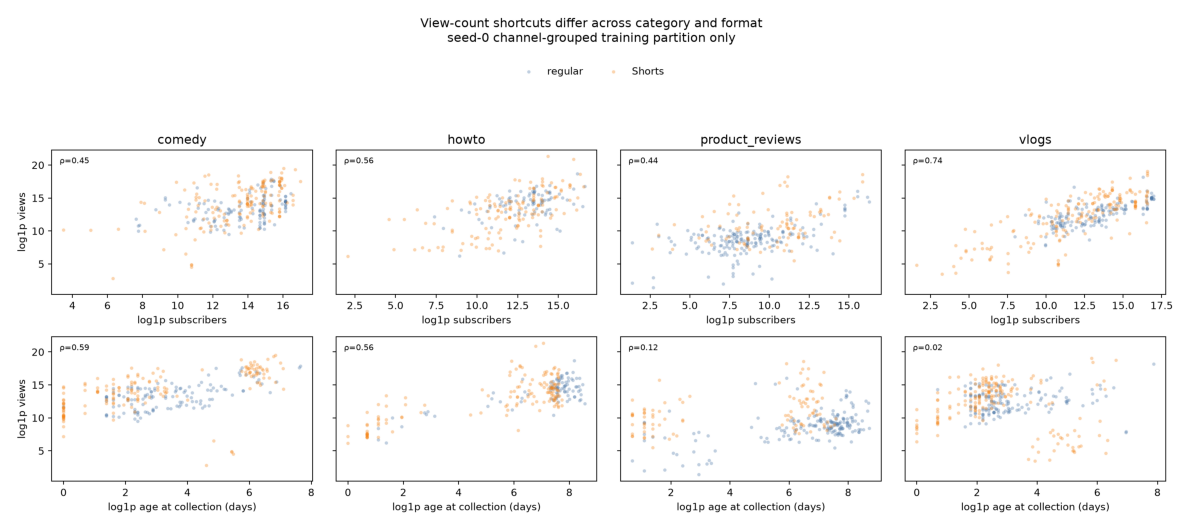

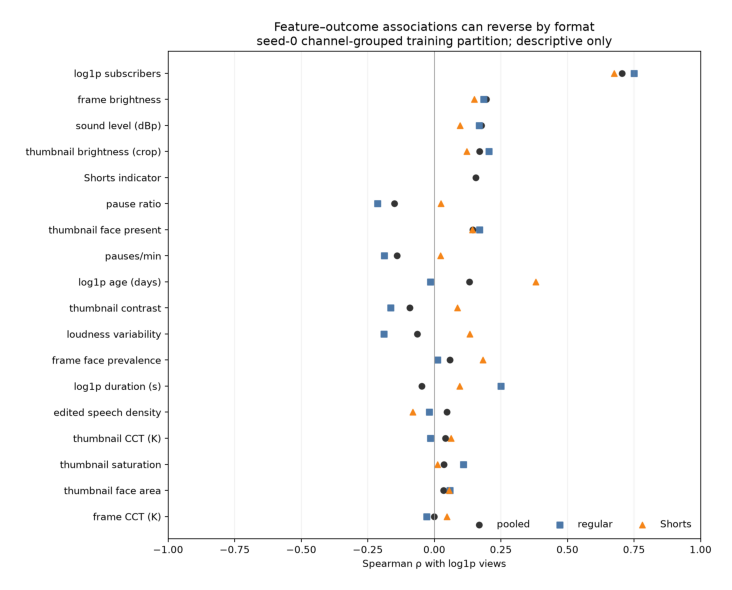

In [15]:
# These figures are generated by eda_features.py from the same tables above.
EDA_OUT = os.path.join(ROOT, "02_Data", "eda_features")
for filename in ("duration_by_category_format.png",
                 "visual_profiles_by_format.png",
                 "audio_speech_by_format.png",
                 "correlation_heatmap_train_seed0.png",
                 "audio_correlation_clustered.png",
                 "modality_coverage_heatmap.png",
                 "shortcut_scatterplots_train_seed0.png",
                 "outcome_associations_train_seed0.png"):
    path = os.path.join(EDA_OUT, filename)
    if not os.path.exists(path):
        raise FileNotFoundError(f"missing {path}; run: python 02_Data/eda_features.py")
    image = plt.imread(path)
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.imshow(image); ax.axis("off"); plt.tight_layout(); plt.show()

In [16]:
# The decision record is machine-readable so rejected ideas do not quietly return
# under a new column name later.
with open(os.path.join(EDA_OUT, "eda_features_stats.json"), encoding="utf-8") as f:
    eda_decisions = json.load(f)
print("SELECTED:")
for item in eda_decisions["selected_for_eda"]:
    print("  +", item)
print("\nNOT SELECTED:")
for item, reason in eda_decisions["not_selected"].items():
    print(f"  - {item}: {reason}")
print("\nMEASUREMENT LIMITS:")
for item, warning in eda_decisions["known_measurement_limits"].items():
    print(f"  ! {item}: {warning}")

SELECTED:
  + duration by category and format
  + CCT with validity coverage
  + brightness/saturation/contrast
  + face presence and conditional geometry
  + pause diagnostics
  + whole-track acoustic level and variability
  + edited transcript word density
  + mean frame-sampling interval
  + category-format pivot table
  + modality coverage heatmap
  + interpretable Spearman heatmap on the seed-0 training partition
  + clustered eGeMAPS redundancy heatmap
  + training-only shortcut scatterplots and outcome associations

NOT SELECTED:
  - music amount: caption tags and VAD do not quantify music reliably
  - cutting pace: 20 sparse frames miss cuts and confound change with sample spacing
  - single-scene: zero threshold crossings among sparse frames does not establish one scene
  - audio quality score: eGeMAPS describes mixed speech/music/ambience, not recording quality
  - full-dataset label association scans: feature selection on the full dataset would contaminate evaluation; dashbo

## 6. One table, both datasets

The two datasets do not have the same features, so each gets an **adapter** that maps it
onto one canonical table with group-prefixed columns. Every experiment is then a choice
of prefixes rather than a second pipeline.

In [17]:
from ytdiag.adapters import load_retrospective
from ytdiag.features import available_groups, select_columns, LABEL_ONLY

df = load_retrospective(DATA)
print(f"{len(df)} rows x {df.shape[1]} columns; groups with data: {available_groups(df)}")
print(f"labelled: {df.label.notna().sum()}  |  viral rate: {df.label.mean():.3f}")

cols = select_columns(df, ("meta", "sched", "vis", "aud"))
print(f"\nmodel-input columns: {len(cols)}")
for p in ("meta", "sched", "vis", "aud"):
    n = [c for c in cols if c.startswith(p + "__")]
    print(f"   {p+'__':8s} {len(n):3d} columns, mean missing {df[n].isna().mean().mean():.1%}")

# the registry refuses to hand out label-only columns as inputs
print("\nlabel-only columns are never selectable:", not any(c in LABEL_ONLY for c in cols))

1860 rows x 137 columns; groups with data: ['meta', 'sched', 'vis', 'aud', 'asset']
labelled: 1854  |  viral rate: 0.236

model-input columns: 125
   meta__    14 columns, mean missing 7.2%
   sched__    4 columns, mean missing 0.3%
   vis__     15 columns, mean missing 2.0%
   aud__     92 columns, mean missing 2.3%

label-only columns are never selectable: True


In [18]:
# Missingness is structural and blocky -- not random. Listwise deletion is impossible.
miss = df[cols].isna()
print("rows that are complete on every input column:", int((~miss.any(axis=1)).sum()), "of", len(df))
top = miss.mean().sort_values(ascending=False).head(8)
print("\nhighest-missing columns:")
print((top*100).round(1).to_string())

rows that are complete on every input column: 0 of 1860

highest-missing columns:
meta__definition_hd                                    100.0
aud__pause_mean_pause_sec                               37.3
vis__thumb_face_centrality                              28.8
aud__pause_pause_ratio                                   1.9
aud__egemaps__F2frequency_sma3nz_amean                   1.9
aud__egemaps__alphaRatioV_sma3nz_amean                   1.9
aud__egemaps__F3amplitudeLogRelF0_sma3nz_stddevNorm      1.9
aud__egemaps__F3amplitudeLogRelF0_sma3nz_amean           1.9


## 7. The label, and the confound it has to remove

"Viral" = the top quarter **within a peer group** of similar channel size, video age and
format — not the top quarter overall. The reason is section 10's claim.

**Claim to verify:** unstratified, Shorts take the viral label at roughly twice their
population share, and format is trivially readable off the frames.

In [19]:
lab = df[df.label.notna()]
print("labelled videos per category, and viral rate:")
print(lab.groupby("meta__category").label.agg(["size", "sum", "mean"]).round(3).to_string())

# what the label WOULD look like without the format stratum: rank on views within category
naive_viral_short = []
for cat, g in lab.groupby("meta__category"):
    g = g.dropna(subset=["view_count", "meta__is_short"])
    k = max(1, len(g)//4)
    top = g.nlargest(k, "view_count")
    naive_viral_short.append({"category": cat,
                              "shorts_share_of_videos": (g.meta__is_short == 1).mean(),
                              "shorts_share_of_naive_viral": (top.meta__is_short == 1).mean(),
                              "shorts_share_of_real_viral": (g[g.label == 1].meta__is_short == 1).mean()})
cmp = pd.DataFrame(naive_viral_short).set_index("category")
cmp["naive_over_rep"] = (cmp.shorts_share_of_naive_viral / cmp.shorts_share_of_videos).round(2)
cmp["stratified_over_rep"] = (cmp.shorts_share_of_real_viral / cmp.shorts_share_of_videos).round(2)
print("\n", cmp[["shorts_share_of_videos", "naive_over_rep", "stratified_over_rep"]].round(3).to_string())
print("\n-> naive: Shorts over-represented among 'viral'. stratified: ~1.0, the confound is gone.")

labelled videos per category, and viral rate:
                 size    sum   mean
meta__category                     
comedy            463  110.0  0.238
howto             373   87.0  0.233
product_reviews   480  113.0  0.235
vlogs             538  128.0  0.238

                  shorts_share_of_videos  naive_over_rep  stratified_over_rep
category                                                                    
comedy                            0.572            1.40                 0.98
howto                             0.614            1.00                 1.01
product_reviews                   0.369            1.76                 0.96
vlogs                             0.565            1.15                 1.01

-> naive: Shorts over-represented among 'viral'. stratified: ~1.0, the confound is gone.


In [20]:
# Why that matters: format is legible from the pixels, so a vision model could
# score well by learning aspect ratio rather than content.
man = pd.read_csv(os.path.join(DATA, "cleaning_manifest.csv"))
m = man.dropna(subset=["frames_portrait"])
m = m[m.is_short.isin(["true", "false"])]
agree = (m.frames_portrait == (m.is_short == "true").astype(int)).mean()
print(f"frames_portrait predicts is_short for {agree:.1%} of videos")
print("\nraw thumbnail brightness by format (a strong composition/padding proxy):")
print(df.dropna(subset=["meta__is_short"]).groupby("meta__is_short").vis__thumb_brightness.median().round(1).to_string())

frames_portrait predicts is_short for nan% of videos

raw thumbnail brightness by format (a strong composition/padding proxy):
meta__is_short
0.0    144.3
1.0     80.3


## 8. Why the split must be grouped by channel

**Claim to verify:** a plain random split lets a model score well by memorising which
channel a video came from. Videos from one channel share a subscriber count, an audience
and a production style, so a channel on both sides of the split is the same video in
disguise.

In [21]:
from ytdiag.split import split_indices
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import cross_val_predict, GroupKFold, StratifiedKFold
from sklearn.metrics import roc_auc_score

idx = split_indices(lab.reset_index(drop=True), seed=SEED)
print({k: len(v) for k, v in idx.items()})
ch = lab.reset_index(drop=True).channel_id.to_numpy()
overlap = set(ch[idx["train"]]) & set(ch[idx["test"]])
print("channels appearing in BOTH train and test:", len(overlap), "(the split asserts this is 0)")
print(f"\n{lab.channel_id.nunique()} channels for {len(lab)} videos; "
      f"{(lab.channel_id.value_counts() == 1).mean():.1%} of channels contribute exactly one video")

{'train': 1113, 'val': 370, 'test': 371}
channels appearing in BOTH train and test: 0 (the split asserts this is 0)

1314 channels for 1854 videos; 81.7% of channels contribute exactly one video


In [22]:
# The leak, measured. Predict the label from CHANNEL-LEVEL features only.
sub = lab.dropna(subset=["meta__channel_follower_count", "meta__channel_age_days"]).copy()
X = sub[["meta__channel_follower_count", "meta__channel_age_days", "meta__channel_video_count"]].astype(float)
y = sub.label.astype(int).to_numpy()

def auc(cv, groups=None):
    p = cross_val_predict(HistGradientBoostingClassifier(random_state=SEED), X, y,
                          cv=cv, groups=groups, method="predict_proba")[:, 1]
    return roc_auc_score(y, p)

print(f"channel features, RANDOM folds  : AUC {auc(StratifiedKFold(5, shuffle=True, random_state=SEED)):.3f}")
print(f"channel features, GROUPED folds : AUC {auc(GroupKFold(n_splits=5), sub.channel_id):.3f}")
print("\n-> the gap is the memorisation a non-grouped split would hand you for free.")

channel features, RANDOM folds  : AUC 0.644


channel features, GROUPED folds : AUC 0.580

-> the gap is the memorisation a non-grouped split would hand you for free.


## 9. The baselines

`dummy_prior` predicts the class prior, so it scores 0.5 by construction — that is the
floor every other number is read against. The **test split is not touched here**; it is
evaluated once, at the end of the project.

Note the spread across seeds: with ~370 validation rows a single seed is not a result.

In [23]:
from ytdiag.baselines import run_baselines, format_results

res = run_baselines(df, ("meta", "sched"), seed=SEED)
print(format_results(res))

groups=['meta', 'sched']  features=17  split={'train': 1113, 'val': 370, 'test': 371}
  dropped 1 all-NaN column(s): meta__definition_hd
  dummy_prior              val AUC 0.500  PR-AUC 0.238  F1@0.05 0.384
  logistic_regression      val AUC 0.617  PR-AUC 0.357  F1@0.17 0.415
  xgboost                  val AUC 0.632  PR-AUC 0.342  F1@0.14 0.442


In [24]:
# Ablation across feature groups, averaged over seeds so the numbers mean something.
SEEDS = range(3)   # raise to 5+ if you have a minute
rows = []
for groups in [("meta",), ("meta", "sched"), ("meta", "sched", "vis"),
               ("meta", "sched", "vis", "aud"), ("vis",), ("aud",)]:
    per = {}
    for s in SEEDS:
        r = run_baselines(df, groups, seed=s)
        for name, v in r["models"].items():
            per.setdefault(name, []).append(v["val"]["auc_roc"])
    for name, vals in per.items():
        rows.append({"groups": ",".join(groups), "model": name,
                     "val_auc_mean": np.mean(vals), "val_auc_std": np.std(vals)})
abl = pd.DataFrame(rows).pivot_table(index="groups", columns="model",
                                     values=["val_auc_mean", "val_auc_std"])
print(abl.round(3).to_string())

                   val_auc_mean                             val_auc_std                            
model               dummy_prior logistic_regression xgboost dummy_prior logistic_regression xgboost
groups                                                                                             
aud                         0.5               0.549   0.583         0.0               0.020   0.029
meta                        0.5               0.617   0.572         0.0               0.023   0.039
meta,sched                  0.5               0.624   0.586         0.0               0.027   0.034
meta,sched,vis              0.5               0.623   0.566         0.0               0.018   0.019
meta,sched,vis,aud          0.5               0.617   0.622         0.0               0.025   0.028
vis                         0.5               0.514   0.502         0.0               0.017   0.013


### Nested tuning changes the baseline to beat

The table above keeps the original fixed configurations as reproducible floors.
The final comparator uses four channel-grouped folds inside each outer training
set to select hyperparameters and its F1 threshold. Outer validation is used only
for evaluation and the test split remains sealed.

**Claim to verify:** tuning helps XGBoost, not every model, and makes
metadata+schedule the strongest structured feature set.

In [25]:
TUNED_RESULTS = os.path.join(ROOT, "05_Reports", "final_report", "results", "tuned_baselines.json")
with open(TUNED_RESULTS, encoding="utf-8") as f:
    tuned = json.load(f)

rows = []
for feature_set, result in tuned["feature_sets"].items():
    for model in ("logistic_regression", "xgboost"):
        fixed = result["untuned_reference"][model]
        selected = result["aggregate"][model]["auc_roc"]
        rows.append({
            "features": feature_set, "model": model,
            "fixed_auc": f"{fixed['mean']:.3f} ± {fixed['std']:.3f}",
            "tuned_auc": f"{selected['mean']:.3f} ± {selected['std']:.3f}",
        })
print(pd.DataFrame(rows).set_index(["features", "model"]).to_string())
print("\nselection: inner channel-grouped training folds; test untouched")

                                            fixed_auc      tuned_auc
features           model                                            
meta+sched         logistic_regression  0.597 ± 0.055  0.590 ± 0.048
                   xgboost              0.589 ± 0.028  0.619 ± 0.022
meta+sched+vis+aud logistic_regression  0.587 ± 0.042  0.595 ± 0.032
                   xgboost              0.605 ± 0.030  0.614 ± 0.023

selection: inner channel-grouped training folds; test untouched


## 10. Frozen deep multimodal result

The encoders are intentionally **not** rerun inside this walkthrough: generating
DINOv2 and 1,024-token ModernBERT embeddings is a one-time accelerated job, not
a notebook check. This cell reads the tracked five-seed evidence produced by
`run_deep_multimodal.py` and shows whether raw content beat the tabular bar.

**Claim to verify:** the frozen thumbnail/text model did not beat the engineered
baseline, and its nonlinear fusion was more variable rather than better.

In [26]:
DEEP_RESULTS = os.path.join(ROOT, "05_Reports", "final_report", "results", "deep_multimodal.json")
with open(DEEP_RESULTS, encoding="utf-8") as f:
    deep = json.load(f)

rows = []
for inputs, models in deep["aggregate"].items():
    row = {"inputs": inputs}
    for model in ("linear_probe", "late_fusion_mlp"):
        auc = models[model]["auc_roc"]
        row[model] = f"{auc['mean']:.3f} ± {auc['std']:.3f}"
    rows.append(row)
print(pd.DataFrame(rows).set_index("inputs").to_string())

refs = {
    "tuned_metadata_schedule_xgboost": tuned["feature_sets"]["meta+sched"]["aggregate"]["xgboost"]["auc_roc"],
    "tuned_full_engineered_xgboost": tuned["feature_sets"]["meta+sched+vis+aud"]["aggregate"]["xgboost"]["auc_roc"],
}
print("\nbaselines to beat:")
for name, result in refs.items():
    print(f"  {name:30s} {result['mean']:.3f} ± {result['std']:.3f}")
full = deep["aggregate"]["thumbnail_text_meta_sched"]["late_fusion_mlp"]["auc_roc"]["values"]
print(f"\nfull MLP seed range: {min(full):.3f}–{max(full):.3f}; test untouched")

                            linear_probe late_fusion_mlp
inputs                                                  
thumbnail                  0.563 ± 0.032   0.547 ± 0.019
text                       0.523 ± 0.038   0.512 ± 0.055
thumbnail_text             0.551 ± 0.041   0.531 ± 0.033
thumbnail_text_meta_sched  0.570 ± 0.051   0.554 ± 0.022

baselines to beat:
  tuned_metadata_schedule_xgboost 0.619 ± 0.022
  tuned_full_engineered_xgboost  0.614 ± 0.023

full MLP seed range: 0.534–0.594; test untouched


### Targeted field-aware text follow-up

The generic concatenated text result justified one controlled retry, not a
larger end-to-end model. The follow-up uses an embedding-trained ModernBERT,
encodes title, description and quality-gated transcript separately, and samples
long transcripts across up to four chunks. This cell reads the tracked evidence;
it does not rerun the encoder.

**Claim to verify:** text v2 adds measurable content signal but remains below the
strongest tuned baseline; the five paired seeds do not support a content-model win.

In [27]:
TEXT_V2_RESULTS = os.path.join(ROOT, "05_Reports", "final_report", "results", "text_v2.json")
with open(TEXT_V2_RESULTS, encoding="utf-8") as f:
    text_v2 = json.load(f)

show = ["title_description", "transcript", "text_fields",
        "text_fields_meta_sched", "thumbnail_text_fields_meta_sched"]
rows = []
for inputs in show:
    models = text_v2["aggregate"][inputs]
    row = {"inputs": inputs}
    for model in ("linear_probe", "late_fusion_mlp"):
        auc = models[model]["auc_roc"]
        row[model] = f"{auc['mean']:.3f} ± {auc['std']:.3f}"
    rows.append(row)
print(pd.DataFrame(rows).set_index("inputs").to_string())

best = text_v2["aggregate"]["thumbnail_text_fields_meta_sched"]["late_fusion_mlp"]["auc_roc"]
for name in ("metadata_schedule_xgboost", "full_engineered_xgboost"):
    ref = text_v2["references"][name]
    diffs = np.asarray(best["values"]) - np.asarray(ref["values"])
    print(f"\n{name}: mean delta {diffs.mean():+.3f}; paired wins {(diffs > 0).sum()}/5")
print("test untouched")

                                   linear_probe late_fusion_mlp
inputs                                                         
title_description                 0.531 ± 0.045   0.528 ± 0.036
transcript                        0.562 ± 0.028   0.537 ± 0.016
text_fields                       0.568 ± 0.018   0.571 ± 0.004
text_fields_meta_sched            0.581 ± 0.023   0.581 ± 0.020
thumbnail_text_fields_meta_sched  0.587 ± 0.033   0.600 ± 0.026

metadata_schedule_xgboost: mean delta -0.019; paired wins 1/5

full_engineered_xgboost: mean delta -0.014; paired wins 3/5
test untouched


### Did hyperparameter tuning rescue the deep head?

This post-hoc robustness check expands both the linear regularisation grid and
the trainable MLP head while keeping all encoders frozen. Each outer seed uses
three inner grouped folds for model selection and a further grouped monitor
split for epoch selection.

**Claim to verify:** the larger search does not improve the pre-specified head
and increases split-to-split variability.

In [28]:
TUNED_DEEP_RESULTS = os.path.join(ROOT, "05_Reports", "final_report", "results", "tuned_deep.json")
with open(TUNED_DEEP_RESULTS, encoding="utf-8") as f:
    tuned_deep = json.load(f)

name = "thumbnail_text_fields_meta_sched"
rows = []
for model in ("linear_probe", "late_fusion_mlp"):
    tuned_auc = tuned_deep["aggregate"][name][model]["auc_roc"]
    comparison = tuned_deep["comparisons"][model]
    fixed_auc = comparison["fixed"]
    rows.append({
        "head": model,
        "pre_specified": f"{fixed_auc['mean']:.3f} ± {fixed_auc['std']:.3f}",
        "nested_tuned": f"{tuned_auc['mean']:.3f} ± {tuned_auc['std']:.3f}",
        "tuned_wins": f"{comparison['tuned_wins_vs_fixed']}/5",
    })
print(pd.DataFrame(rows).set_index("head").to_string())
print("\nencoders frozen; outer validation only; test untouched")

                 pre_specified   nested_tuned tuned_wins
head                                                    
linear_probe     0.587 ± 0.033  0.587 ± 0.034        1/5
late_fusion_mlp  0.600 ± 0.026  0.598 ± 0.037        2/5

encoders frozen; outer validation only; test untouched


## 11. The most important number in the project

**Claim to verify:** a model given only subscriber count, video age, duration and
Shorts-status — **no content at all** — already predicts log(views) well. That is why
raw views can never be the reported target, and why the label ranks within a peer group.

In [29]:
from eda_retrospective import load, shortcut_ceiling

d = load()
sc = shortcut_ceiling(d)
print("out-of-fold R^2 of log(views) from four no-content confounds, grouped by channel:")
for scope, v in sc.items():
    print(f"   {scope:16s} R^2 {v['r2_oof']:.3f}   (n={v['n']})")
print("\nrank correlation of each confound with log(views), pooled:")
for k, val in sc["all"].items():
    if k.startswith("spearman"):
        print(f"   {k.replace('spearman_',''):32s} {val}")

out-of-fold R^2 of log(views) from four no-content confounds, grouped by channel:
   all              R^2 0.584   (n=1860)
   comedy           R^2 0.428   (n=464)
   howto            R^2 0.621   (n=373)
   product_reviews  R^2 0.519   (n=482)
   vlogs            R^2 0.647   (n=541)

rank correlation of each confound with log(views), pooled:
   meta__channel_follower_count     0.708
   age_days                         0.151
   meta__duration_sec               -0.042
   meta__is_short                   0.153


### Where to go next

- `02_Data/eda.md` — the label analysis and the three decisions it settled
- `02_Data/eda_features.md` — the label-blind modality EDA and measurement limits
- `05_Reports/final_report/results/tuned_baselines.json` — nested tuned comparators
- `05_Reports/final_report/results/deep_multimodal.json` — the frozen-content result
- `05_Reports/final_report/results/text_v2.json` — the field-aware text follow-up
- `05_Reports/final_report/results/tuned_deep.json` — nested fusion-head search
- `KNOWN_ISSUES.md` — real defects found but not yet fixed
- `tests/` — the guards; all pipeline, tuning, and deep suites run offline

If you change anything in `02_Data/` or `03_Models/`, re-run the tests rather than
re-running this notebook: the notebook demonstrates, the tests verify.